In [2]:
import bisect
import pretty_midi
import numpy as np
import librosa.display
import matplotlib.pyplot as plt
from midi_player import MIDIPlayer
from midi_player.stylers import basic, cifka_advanced


c:\Users\bicro18p\AppData\Local\anaconda3\envs\bass_app_env\lib\site-packages\pretty_midi\instrument.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
midi_file_path = "transcribed_output/bass_NGHYB_std_transcribed.mid"

midi_data = pretty_midi.PrettyMIDI(midi_file_path)

In [4]:
def get_midi_sample(midi_data, sample_start, sample_end): 
    #make new midi object in case objects perform shallow copy
    midi_sample = pretty_midi.PrettyMIDI()
    bass_program = pretty_midi.instrument_name_to_program("Acoustic Bass")
    bass_sample = pretty_midi.Instrument(program=bass_program)

    notes = midi_data.instruments[0].notes
    note_ends = [note.end for note in notes]

    start_note_index = bisect.bisect_left(note_ends, sample_start)
    end_note_index = bisect.bisect_left(note_ends, sample_end)

    bass_sample.notes = notes[start_note_index:end_note_index]
    midi_sample.instruments.append(bass_sample)

    return midi_sample

In [5]:
# get_midi_sample(midi_data, sample_start=0, sample_end=20)
# get_midi_sample(midi_data,sample_end=20)

In [6]:
# piano_roll = midi_data.get_piano_roll(fs=100) # fs is the sampling frequency in Hz

In [14]:
def plot_piano_roll(midi_data, start_pitch, end_pitch, fs=100, sample_start = None, sample_end = None, visualise_strums = False):
    if sample_start == None:
        #no provided start means set to 0
        sample_start = 0
    if sample_end == None:
        #no proivided end means take the last time 
        sample_end = midi_data.instruments[0].notes[-1].end
    
    #get sample depending on times given
    #if both are none then it is equal to the original
    pm = get_midi_sample(midi_data,sample_start = sample_start, sample_end=sample_end)
    
    # Use librosa's specshow function for displaying the piano roll
    piano_roll = pm.get_piano_roll(fs)
    piano_roll_frames_within_pitch = np.array(piano_roll[start_pitch:end_pitch])
    
    librosa.display.specshow(piano_roll_frames_within_pitch,
                             hop_length=1, sr=fs, x_axis='time', y_axis='cqt_note',
                             fmin=pretty_midi.note_number_to_hz(start_pitch))
    plt.xlim(sample_start, sample_end)
    # librosa.display.specshow(pm.get_piano_roll(fs)[start_pitch:end_pitch],
    #                          hop_length=1, sr=fs, x_axis='time', y_axis='cqt_note',
    #                          fmin=pretty_midi.note_number_to_hz(start_pitch))
    if visualise_strums:
        start_notes = [note.end for note in pm.instruments[0].notes]
        for s in start_notes:
            plt.axvline(x=s, color='g', linewidth=0.5, linestyle="-")

In [15]:
# get strum times from sample
sample_start = 0
sample_end = 20
pm = get_midi_sample(midi_data,sample_start = sample_start, sample_end=sample_end)

start_notes = [note.end for note in pm.instruments[0].notes]
# start_notes

C:\Users\local_bicro18p\Temp\ipykernel_23064\2664591954.py:17: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  librosa.display.specshow(piano_roll_frames_within_pitch,


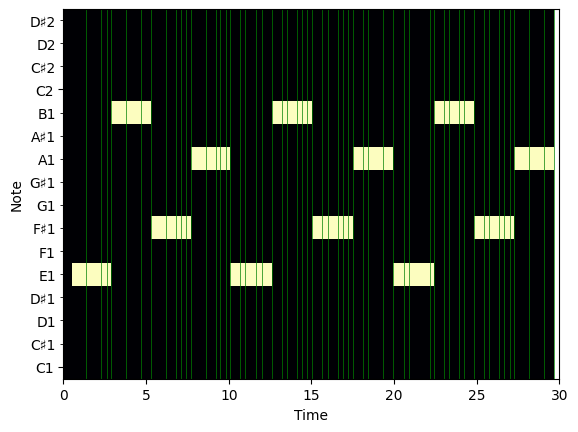

In [18]:
# plt.figure(figsize=(12, 4))
plot_piano_roll(midi_data, 24, 40,sample_start= 0, sample_end = 30, visualise_strums=True)

In [10]:
MIDIPlayer(midi_file_path, 160, styler=cifka_advanced, title='My Player')